# GUV Image Analysis Pipeline

This notebook contains a pipeline for analyzing GUV (Giant Unilamellar Vesicle) images. It processes both single-frame and time-trace data from .tif files.

(under construction)

In [1]:
import csv
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from openpyxl import load_workbook
from scipy.interpolate import make_interp_spline

# Import custom modules
import vesicles as vs

# set up autoreload on all files
%load_ext autoreload
%autoreload 2


### GUV Class Definition

In [2]:
class GUV:
    def __init__(self):
        self.exp_id = 0
        self.label = 'any_label'
        self.comment = []
        self.use_it = []
        self.crop_it = []
        self.dt = 1

## Helper Functions

### `get_data_selections(run_id)`

This function reads GUV data from an Excel file and returns a list of GUV objects for a specific run ID.
We define a `GUV` class to store properties of a single GUV movie.

In [4]:
def get_data_selections(run_id,filename):
    wb = load_workbook(filename)
    sheet_files = wb['guvs']
    
    # Create a dictionary of column names
    Header = {COL[0].value: idx for idx, COL in enumerate(sheet_files.iter_cols(1, sheet_files.max_column))}
    
    Guv_list = []
    for row_cells in sheet_files.iter_rows(min_row=2, max_row=sheet_files.max_row):
        Guv = GUV()
        Guv.exp_id = row_cells[Header["exp_id"]].value
        Guv.movie_id = row_cells[Header["movie_id"]].value
        Guv.label = row_cells[Header["guv_label"]].value
        Guv.use_it = row_cells[Header["use"]].value
        Guv.crop_it = row_cells[Header["crop"]].value
        Guv.dt = row_cells[Header["dt(s)"]].value
        if Guv.exp_id == run_id:
            Guv_list.append(Guv)
    return Guv_list

## Main Analysis Pipeline

The main analysis is divided in a few main steps. For historical reasons, these are labeled A00, A10 ...etc. These lalbels are also used for the organization of saved data (pictures, tables) so that one can backtrack this data to the generating code.

### A00: set up the experiment
Fetch the experiment parameters: these are listed in 'A00_init and include paths, movienames etc.'. An experiment has a unique index. Since I keep some local copies, I added a decimal to this index to tell the code where to look (local or remote)

In [5]:
from vesicles import A00_init
expi = 0.2  
    # 0.2: Charu's test data, C=1, decimal .2 refers to remote drive
    # 1.2: Charu's test data, C=2, decimal .2 refers to remote drive
movie_to_use_list = [0]  #should be identical to 'movie-id' list in excel
movie_simbol_list = ['r']

initval = A00_init.get_exps(expi)

### A10: Cropping
With cropping, we cut out indivdidual vesicles from the stack and save them to individual tiff files. We do this because this eases the follow-up analysis: each stack is assumed to contain only one full vesicle in the center, with approximately a constant coverage of the middle area of the ROI.
This step requires the user to perform (easy) pre-selection in Fiji or ImageJ. Please read the README.txt for detailed info how to do that.

C:\Users\jkerssemakers\OneDrive - Delft University of Technology\CD_recent\BN_CD25_Charu\analysis\CD23_Vesicles\vesicles\common_tools\guv_io.py:385: RuntimeWarning: divide by zero encountered in log
  ovv_im=np.log(chan)


a10:from_20082025_CS_For Jacob.lif - R 4_Merged - C=1_roi0_c0.tif
a10:from_20082025_CS_For Jacob.lif - R 4_Merged - C=1_roi1_c0.tif


C:\Users\jkerssemakers\OneDrive - Delft University of Technology\CD_recent\BN_CD25_Charu\analysis\CD23_Vesicles\vesicles\common_tools\guv_io.py:407: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


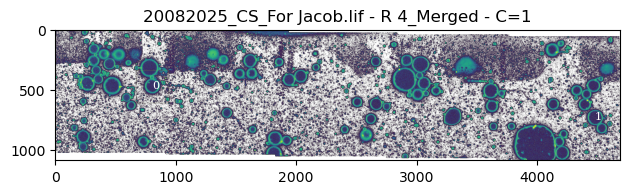

In [10]:
from vesicles import A10_muscope_crop

A10_muscope_crop.main(initval)
dum=1

dum=2

## A20: First processing of regions-of-interest (ROIs)
In this step, we first isolate the area of the vesicle to obtain masks, but also some general geometry features such as radius, area and other shape characteristics. Next, we perfom detailed analysis of every color channel 

In [8]:
from vesicles import A20_process_rois

A20_process_rois.main(initval)

a20a:file_20082025_CS_For Jacob.lif - R 4_Merged - C=1_roi0c0frame0
a20a:file_20082025_CS_For Jacob.lif - R 4_Merged - C=1_roi1c0frame0
a20a:file_20082025_CS_For Jacob.lif - R 4_Merged - C=1_roi2c0frame0
a20a:file_20082025_CS_For Jacob.lif - R 4_Merged - C=1_roi3c0frame0
a20a:file_20082025_CS_For Jacob.lif - R 4_Merged - C=1_roi4c0frame0
a20a:file_20082025_CS_For Jacob.lif - R 4_Merged - C=1_roi5c0frame0
a20a:file_20082025_CS_For Jacob.lif - R 4_Merged - C=1_roi6c0frame0
a20a:file_20082025_CS_For Jacob.lif - R 4_Merged - C=1_roi7c0frame0
a20a:file_20082025_CS_For Jacob.lif - R 4_Merged - C=1_roi8c0frame0
a20a:file_20082025_CS_For Jacob.lif - R 4_Merged - C=1_roi9c0frame0
a20a:file_20082025_CS_For Jacob.lif - R 4_Merged - C=1_roi10c0frame0
a20a:file_20082025_CS_For Jacob.lif - R 4_Merged - C=1_roi11c0frame0
a20a:file_20082025_CS_For Jacob.lif - R 4_Merged - C=1_roi12c0frame0
a20a:file_20082025_CS_For Jacob.lif - R 4_Merged - C=1_roi13c0frame0
a20a:file_20082025_CS_For Jacob.lif - R 4_Me

c:\Users\jkerssemakers\OneDrive - Delft University of Technology\CD_recent\BN_CD25_Charu\analysis\CD23_Vesicles\vesicles\common_tools\guv_tools.py:280: RuntimeWarning: divide by zero encountered in scalar divide
  angularstep=np.pi/2/spokesnoperquad #This is the step size of the angles
c:\Users\jkerssemakers\OneDrive - Delft University of Technology\CD_recent\BN_CD25_Charu\analysis\CD23_Vesicles\vesicles\common_tools\guv_process_stacks.py:383: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  axs1[0].imshow(edge_map)
c:\Users\jkerssemakers\OneDrive - Delft University of Technology\CD_recent\BN_CD25_Charu\analysis\CD23_Vesicles\vesicles\common_tools\guv_process_stacks.py:383: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  axs1[0].imshow(edge_map)


a20b:file_20082025_CS_For Jacob.lif - R 4_Merged - C=1_roi7c0frame0
a20b:file_20082025_CS_For Jacob.lif - R 4_Merged - C=1_roi8c0frame0
a20b:file_20082025_CS_For Jacob.lif - R 4_Merged - C=1_roi9c0frame0
a20b:file_20082025_CS_For Jacob.lif - R 4_Merged - C=1_roi10c0frame0
a20b:file_20082025_CS_For Jacob.lif - R 4_Merged - C=1_roi11c0frame0
a20b:file_20082025_CS_For Jacob.lif - R 4_Merged - C=1_roi12c0frame0
a20b:file_20082025_CS_For Jacob.lif - R 4_Merged - C=1_roi13c0frame0
a20b:file_20082025_CS_For Jacob.lif - R 4_Merged - C=1_roi14c0frame0
a20b:file_20082025_CS_For Jacob.lif - R 4_Merged - C=1_roi15c0frame0
a20b:file_20082025_CS_For Jacob.lif - R 4_Merged - C=1_roi16c0frame0
a20b:file_20082025_CS_For Jacob.lif - R 4_Merged - C=1_roi17c0frame0
a20b:file_20082025_CS_For Jacob.lif - R 4_Merged - C=1_roi18c0frame0
a20b:file_20082025_CS_For Jacob.lif - R 4_Merged - C=1_roi19c0frame0
a20b:file_20082025_CS_For Jacob.lif - R 4_Merged - C=1_roi20c0frame0
a20b:file_20082025_CS_For Jacob.lif -

### I. Single-frame Data Processing

If the data is single-frame .tif files, we just collect all data points and save them in one file.

In [9]:
if initval.suffix == '.tif' and initval.sequence == 'single_frame':
    load_dirname = initval.mainpath_out + initval.subdir + "/A20b_processed/"
    csv_path_in = Path(load_dirname)
    
    # Collect data from all CSV files
    name, data = [], []
    for csv_source in csv_path_in.glob("**/*.csv"):
        print(csv_source.stem)
        with open(csv_source) as f:
            reader = csv.DictReader(f, delimiter=";")
            for row in reader:
                name.append(csv_source.stem)
                data.append(row)
    
    # Save collected data to a new CSV file
    csv_path_out = Path(initval.mainpath_out + initval.subdir + "/A30_processed/")
    csv_path_out.mkdir(exist_ok=True)
    
    csv_target = load_dirname + "collected_data.csv"
    with open(csv_target, "w", newline='') as csv_f:
        writer = csv.writer(csv_f, delimiter=";")
        writer.writerow(data[0].keys())
        for data_row in data:
            writer.writerow(data_row.values())

### II. Multi-frame Data Processing and Visualization

For time-trace or z-plane .tif files, we process the data and create visualizations. Since these movies can have some time slots-of-interest, we load an extra excel table that allows a user to crop dat a of processed movies (or discard them at all). Note that the 'movie-I' field should match the above movie-IDs.

In [10]:
selections_filename="data_overview_Charu.xlsx"
Guv_list = get_data_selections(round(expi), selections_filename)

if initval.suffix == '.tif' and initval.sequence == 'time_trace':
    fig, axs = plt.subplots(2, 4, figsize=(20, 15))
    load_dirname_A20a = initval.mainpath_out + initval.subdir + "/A20a_tracked/"
    load_dirname_A20b = initval.mainpath_out + initval.subdir + "/A20b_processed/"    
    guv_labels = []    
    for this_guv in Guv_list:
        if this_guv.use_it == 1 and this_guv.movie_id in movie_to_use_list:
            movie_use_index = movie_to_use_list.index(this_guv.movie_id)
            guv_labels.append(this_guv.label)
            
            # Read data from CSV
            csv_source = Path(load_dirname_A20b + this_guv.label + "_all_data.csv")
            with open(csv_source) as g:
                reader = csv.DictReader(g, delimiter=";")
                data = list(reader)            
            # Process and plot data
            plot_ax, area, roundness, major_minor = [], [], [], []
            c0_edge_mx, c0_edge_sm = [], []
            
            for fri, row in enumerate(data):
                # ... (data processing code)
                c0_mean_peaks=(float(row['c0_edge_mx']))
                c0_sum=float(row['c0_edge_sum'])
                okay_point=1
                if okay_point:
                    #fetch work parameters:
                    axis_major=float(row['R_major'])
                    axis_minor=float(row['R_minor'])
                    c0_mean_peaks=(float(row['c0_edge_mx']))
                    #build plots:
                    if 1:
                        plot_ax.append(this_guv.dt*fri)
                        axlabel="time (s)"
                    area.append(float(row['area']))
                    roundness.append(float(row['roundness']))
                    c0_edge_mx.append(c0_mean_peaks)
                    c0_edge_sm.append(float(row['c0_edge_sum']))
            
            simbol_color = movie_simbol_list[movie_use_index]
            sz = 2            
            # Plot various metrics
            axs[0, 0].plot(plot_ax, area, 'o-', markersize=sz, color=simbol_color)
            axs[0, 0].set_ylabel("area")
            axs[0, 0].set_title("area")
            
            # ... (more plotting code for other metrics)    
    plt.tight_layout()
    plt.show()

PermissionError: [Errno 13] Permission denied: 'data_overview_Charu.xlsx'

This completes the GUV image analysis pipeline. The notebook processes both single-frame and time-trace .tif files, collecting data and creating visualizations for various GUV metrics.